In [1]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('world_data_full_apply_nulos.csv', index_col=0)

-Trabajaremos con estas variables numéricas:

population

density

life_expectancy

fertility_rate

gdp

Calcula, para cada una de estas variables:

Media

Mediana

Desviación estándar

Mínimo

Máximo

In [6]:
df[['population', 'density', 'life_expectancy', 'fertility_rate','gdp']].describe().T

,count,mean,std,min,25%,50%,75%,max
population,39.0,3.335427e+02,2.964675e+02,1.008400e+01,8.713000e+01,2.150560e+02,5.561625e+02,9.735600e+02
density,195.0,1.345045e+02,1.573068e+02,1.265000e+00,2.616850e+01,8.300000e+01,1.655000e+02,8.470000e+02
life_expectancy,187.0,7.227968e+01,7.483661e+00,5.280000e+01,6.700000e+01,7.320000e+01,7.750000e+01,8.540000e+01
fertility_rate,188.0,2.698138e+00,1.282267e+00,9.800000e-01,1.705000e+00,2.245000e+00,3.597500e+00,6.910000e+00
gdp,193.0,4.772959e+11,2.172173e+12,4.727146e+07,8.454620e+09,3.438723e+10,2.340940e+11,2.142770e+13


In [11]:
desv = df['density'].std()
media = df['density'].mean()
cv = (desv / media)*100

print(cv) # como es mayor al 30%, tiene una alta variación de datos.

116.95276761420712


In [ ]:
desv = df['population'].std()
media = df['population'].mean()
cv1 = (desv / media)*100

print(cv1) # como es mayor al 30%, tiene una alta variación de datos.

88.8844181092542


In [12]:
grupos = df.groupby('population')['density'].agg([
    ('Media', 'mean'),
    ('Desviación Estándar', 'std'),
    ('Varianza', 'var'),
    ('IQR', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    ('CV%', lambda x: (x.std() / x.mean()) * 100)
])

print("=" * 70)
print("COMPARACIÓN DE DISPERSIÓN ENTRE REGIONES")
print("=" * 70)
print(grupos)
print("=" * 70)

COMPARACIÓN DE DISPERSIÓN ENTRE REGIONES
              Media  Desviación Estándar  Varianza  IQR  CV%
population                                                  
10.084      541.000                  NaN       NaN  0.0  NaN
11.646      393.000                  NaN       NaN  0.0  NaN
18.233       39.000                  NaN       NaN  0.0  NaN
33.860      566.000                  NaN       NaN  0.0  NaN
38.019      238.000                  NaN       NaN  0.0  NaN
38.964       26.337                  NaN       NaN  0.0  NaN
52.823      205.000                  NaN       NaN  0.0  NaN
58.791      329.000                  NaN       NaN  0.0  NaN
71.808       96.000                  NaN       NaN  0.0  NaN
77.142      164.000                  NaN       NaN  0.0  NaN
97.118      223.000                  NaN       NaN  0.0  NaN
97.625      214.000                  NaN       NaN  0.0  NaN
100.209     147.000                  NaN       NaN  0.0  NaN
100.455     284.000                  NaN    


Interpreta:

Elige dos variables y comenta si la media y la mediana están próximas o muy separadas.

¿Qué te sugiere esto sobre la posible presencia de valores extremos (outliers)?

-Population : hay una gran diferencia ente la media y la mediana. Esto nos da a enteder que hay algunos valores que están muy alejados del resto.
-density: la diferencia es aún mayor. Hay muchos valores alejados del centro

Variables:

life_expectancy

fertility_rate

Para cada variable:

Muestra un histograma.

Calcula la media y la mediana.

In [14]:
df[['life_expectancy', 'fertility_rate']].agg(['mean','median'])

,life_expectancy,fertility_rate
mean,72.279679,2.698138
median,73.200000,2.245000


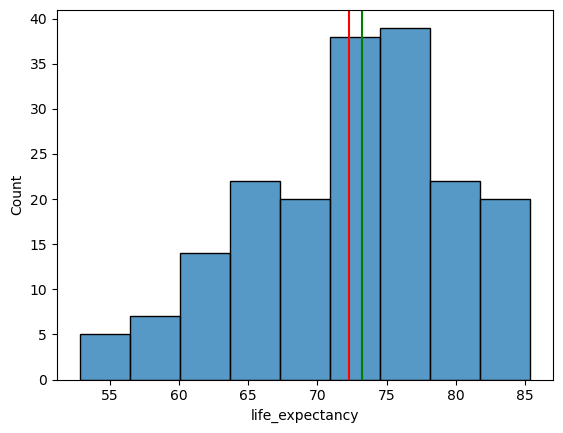

In [18]:
sns.histplot(data=df, x= 'life_expectancy')
plt.axvline(df["life_expectancy"].mean(), color="red") #barra media
plt.axvline(df["life_expectancy"].median(), color="green"); #barra mediana;

Hay una distribucion simetrica, que tiene a un sesgo un poco  mas negativo, con datos que tiran hacia abajo de la media. En este caso la mediana sería un poco más representativa.
La mayoría de los datos son altos.

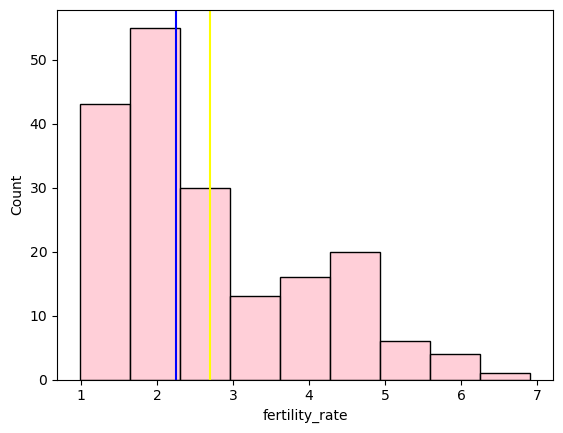

In [19]:
sns.histplot(data=df, x= 'fertility_rate', color= 'pink')
plt.axvline(df["fertility_rate"].mean(), color="yellow") #barra media
plt.axvline(df["fertility_rate"].median(), color="blue"); #barra mediana;

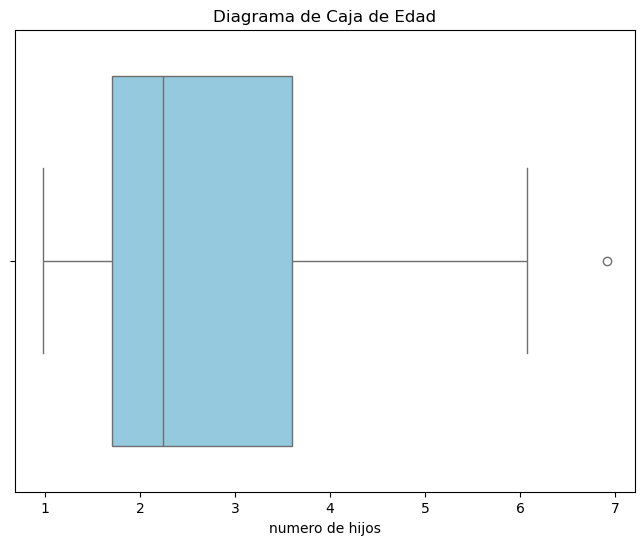

In [20]:
# establecemos el tamaño de la figura
plt.figure(figsize=(8, 6))
# utilizando el método boxplot visualizamos la mediana, cambiamos el color del boxplot
sns.boxplot(x='fertility_rate', 
            data=df, 
            color='skyblue')
# cambiamos el nombre del eje x
plt.xlabel('numero de hijos')
# ponems título a la gráfica
plt.title('Diagrama de Caja de Edad');

Mayoría de valores bajos, la media tira hacia valores mas altos a raiz del outlier 


Interpreta:

¿La distribución parece aproximadamente simétrica, sesgada a la derecha o a la izquierda?

¿En cuál de las dos variables la media se ve más afectada por posibles valores extremos?

¿En cuál te parece más “robusto” el uso de la mediana?